In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/zhaohaoa/cadc/cadc_devkit")

import numpy as np
import load_novatel_data, convert_novatel_to_pose
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Slerp


In [2]:
def load_timestamps(file_path):
    '''
    Load timestamps from a file and convert them to seconds relative to the first timestamp.
    '''
    timestamps = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        start_time_str = lines[0].strip()
        start_time = np.datetime64(start_time_str)
        for line in lines:
            time_str = line.strip()
            time = np.datetime64(time_str)
            delta = (time - start_time) / np.timedelta64(1, 's')
            timestamps.append(float(delta))
    return np.array(timestamps)

In [3]:
def resample_hz(poses, times, target_hz):
    '''
    Resample poses to a target frequency using linear interpolation for translation
    and spherical linear interpolation (SLERP) for rotation.
    Args:
        poses: List or array of (4,4) pose matrices.
        times: List or array of timestamps corresponding to each pose.
        target_hz: Desired frequency in Hz for resampling.
    Returns:
        poses_new: Resampled poses at target frequency.
        times_new: Corresponding timestamps for resampled poses.
    '''

    poses = np.asarray(poses, dtype=float)
    times = np.asarray(times, dtype=float)

    if poses.ndim != 3 or poses.shape[1:] != (4, 4):
        raise ValueError(f"poses must have shape (N,4,4), got {poses.shape}")

    if times.ndim != 1 or times.shape[0] != poses.shape[0]:
        raise ValueError("times must be shape (N,) and match poses")

    # Target time grid
    dt = 1.0 / target_hz
    times_new = np.arange(times[0], times[-1], dt)

    # Translation: linear interpolation
    t = poses[:, :3, 3]
    x = np.interp(times_new, times, t[:, 0])
    y = np.interp(times_new, times, t[:, 1])
    z = np.interp(times_new, times, t[:, 2])

    # Rotation: SciPy SLERP
    R_in = R.from_matrix(poses[:, :3, :3])
    slerp = Slerp(times, R_in)
    R_new = slerp(times_new)

    # --- Assemble output poses ---
    poses_new = np.zeros((len(times_new), 4, 4), dtype=float)
    poses_new[:, 3, 3] = 1.0
    poses_new[:, :3, :3] = R_new.as_matrix()
    poses_new[:, :3, 3] = np.column_stack((x, y, z))

    return poses_new, times_new


def plot_poses(poses, arrow_length=1, step=20, ax=None):
    '''
    Plots 3D vehicle trajectory with orientation arrows.
    Args:
        poses: List or array of (4,4) pose matrices.
        arrow_length: Length of the orientation arrows.
        step: Step size for downsampling arrows to reduce clutter.
    
    poses are in the format:
        [ R | t ]
        [ 0 | 1 ]
    '''

    if ax is None:
        fig = ax.get_figure()
        ax = fig.add_subplot(111, projection='3d')
    

    P = np.asarray(poses)
    if P.ndim != 3 or P.shape[1:] != (4, 4):
        raise ValueError(f"Expected poses shaped (N,4,4), got {P.shape}")
    
    t = P[:, 0:3, 3]      
    fwd = P[:, 0:3, 0]    # forward directions (R[:,0])

    # Trajectory 
    ax.plot(t[:, 0], t[:, 1], t[:, 2], ".", label="Vehicle Trajectory")

    # Downsample arrows to avoid clutter
    idx = np.arange(0, t.shape[0], step)
    ts = t[idx]                 # (M,3)
    fs = fwd[idx]               # (M,3)

    # normalize so all arrows same length
    norms = np.linalg.norm(fs, axis=1, keepdims=True)
    fs_unit = fs / np.clip(norms, 1e-12, None)

    # draw all arrows
    ax.quiver(
        ts[:, 0], ts[:, 1], ts[:, 2],          # starts
        fs_unit[:, 0], fs_unit[:, 1], fs_unit[:, 2],  # directions
        length=arrow_length,
        arrow_length_ratio=0.2,
        # normalize=True,
        color='r',
    )

    ax.set_zlim3d(-5,5)

    ax.set_xlabel("East (m)")
    ax.set_ylabel("North (m)")
    ax.set_zlabel("Up (m)")
    # ax.legend()
    
    return ax

## Infer additional features

Infer command and extract velocities, accelerations.

In [4]:
def infer_direction(
    poses,
    *,
    yaw_deg=12.0,
    min_step=1e-3,                 # ignore tiny steps
):
    
    '''
    Given array of poses, infer direction based on start and end heading.
    Return as 1-hot 4D vector (left, forward, right, unknown)
    Args:
        poses: List or array of (4,4) pose matrices.
        yaw_deg: Minimum yaw angle in degrees to consider a turn.
        min_step: Minimum step distance to consider for forward motion.
    '''
    # output order: [left, forward, right, unknown]
    LEFT, FWD, RIGHT, UNK = 0, 1, 2, 3

    poses = np.asarray(poses)
    if poses.ndim != 3 or poses.shape[1:] != (4, 4) or poses.shape[0] < 2:
        return np.array([0, 0, 0, 1], dtype=np.float32)

    R = poses[:, :3, :3]
    t = poses[:, :3, 3]

    # ---- 1) TURN: accumulate signed yaw from relative rotations (z-up) ----
    total_yaw = 0.0
    for i in range(poses.shape[0] - 1):
        Rrel = R[i].T @ R[i + 1]  # local->world => relative in local at i
        # yaw about +Z (right-hand rule): + => left (CCW), - => right (CW)
        total_yaw += np.arctan2(Rrel[1, 0], Rrel[0, 0])

    total_yaw_deg = np.degrees(total_yaw)
    if total_yaw_deg > yaw_deg:
        return np.array([1, 0, 0, 0], dtype=np.float32)
    if total_yaw_deg < -yaw_deg:
        return np.array([0, 0, 1, 0], dtype=np.float32)

    # ---- 2) STRAIGHT: vote using forward motion in local frame ----
    fwd_sum = 0.0
    used = 0.0
    for i in range(poses.shape[0] - 1):
        dp_world = t[i + 1] - t[i]
        step = float(np.linalg.norm(dp_world))
        if step < min_step:
            continue
        dp_local = R[i].T @ dp_world
        # forward is x
        if dp_local[0] > 0:
            fwd_sum += dp_local[0]
            used += 1.0

    if used > 0 and fwd_sum / used > min_step:
        return np.array([0, 1, 0, 0], dtype=np.float32)

    return np.array([0, 0, 0, 1], dtype=np.float32)

## Process single trajectory

In [5]:
def convert_to_2d(poses):
    '''
    Conver to [x, y, yaw] 2D representation from 4x4 poses.
    Args:
        poses: List or array of (4,4) pose matrices.
    Returns:
        poses_2d: Array of (N, 3) with [x, y, yaw] for each pose.
    ''' 
    poses = np.asarray(poses, dtype=float)
    if poses.ndim != 3 or poses.shape[1:] != (4, 4):
        raise ValueError(f"poses must have shape (N,4,4), got {poses.shape}")
    N = poses.shape[0]
    poses_2d = np.zeros((N, 3), dtype=float)  # [x, y, yaw]
    for i in range(N):
        t = poses[i, :3, 3]
        R_mat = poses[i, :3, :3]
        yaw = np.arctan2(R_mat[1, 0], R_mat[0, 0])  # yaw from rotation matrix
        poses_2d[i] = [t[0], t[1], yaw]
    return poses_2d

def extract_velocities(poses, times):
    '''
    Extract linear velocities from 2D poses and timestamps.
    Args:
        poses: List or array of 2D poses [x, y, yaw].
        times: List or array of timestamps corresponding to each pose.
    Returns:
        velocities: Array of linear velocities (N-1, 2) in m/s.
        times: Corresponding timestamps for velocities (N-1,).
    '''
    poses = np.asarray(poses, dtype=float)
    times = np.asarray(times, dtype=float)
    if poses.ndim != 2 or poses.shape[1] != 3:
        raise ValueError(f"poses must have shape (N,3), got {poses.shape}")
    if times.ndim != 1 or times.shape[0] != poses.shape[0]:
        raise ValueError("times must be shape (N,) and match poses")
    t = poses[:, :2]  # Extract x, y components
    dt = np.diff(times)  # Time differences
    # Compute velocities
    velocities = np.diff(t, axis=0) / dt[:, np.newaxis]  # Shape (N-1, 2)
    vel_times =  0.5 * (times[1:] + times[:-1])
    return velocities, vel_times

def extract_accelerations(velocities, times):
    '''
    Extract linear accelerations from velocities and timestamps.
    Args:
        velocities: List or array of linear velocities (N, 2).
        times: List or array of timestamps corresponding to each velocity.
    Returns:
        accelerations: Array of linear accelerations (N-1, 2) in m/s².
        times: Corresponding timestamps for accelerations (N-1,).
    '''
    velocities = np.asarray(velocities, dtype=float)
    times = np.asarray(times, dtype=float)
    if velocities.ndim != 2 or velocities.shape[1] != 2:
        raise ValueError(f"velocities must have shape (N,2), got {velocities.shape}")
    if times.ndim != 1 or times.shape[0] != velocities.shape[0]:
        raise ValueError("times must be shape (N,) and match velocities")
    dt = np.diff(times)  # Time differences
    # Compute accelerations
    accelerations = np.diff(velocities, axis=0) / dt[:, np.newaxis]  # Shape (N-1, 2)
    acc_times = 0.5 * (times[1:] + times[:-1])
    return accelerations, acc_times

def infer_direction_2d(
    poses,
    *,
    yaw_deg=12.0,
    min_step=1e-3,                 # ignore tiny steps
):
    '''
    Given array of 2D poses [x, y, yaw], infer direction based on start and end heading.
    Return as 1-hot 4D vector (left, forward, right, unknown)
    Args:
        poses: List or array of 2D poses [x, y, yaw].
        yaw_deg: Minimum yaw angle in degrees to consider a turn.
        min_step: Minimum step distance to consider for forward motion.
    '''
    # output order: [left, forward, right, unknown]
    LEFT, FWD, RIGHT, UNK = 0, 1, 2, 3

    poses = np.asarray(poses)
    if poses.ndim != 2 or poses.shape[1] != 3 or poses.shape[0] < 2:
        return np.array([0, 0, 0, 1], dtype=np.float32)

    t = poses[:, :2]
    yaw = poses[:, 2]

    # ---- 1) TURN: accumulate signed yaw differences ----
    total_yaw = 0.0
    for i in range(poses.shape[0] - 1):
        dyaw = yaw[i + 1] - yaw[i]
        # normalize to [-pi, pi]
        dyaw = (dyaw + np.pi) % (2 * np.pi) - np.pi
        total_yaw += dyaw

    total_yaw_deg = np.degrees(total_yaw)
    if total_yaw_deg > yaw_deg:
        return np.array([1, 0, 0, 0], dtype=np.float32)
    if total_yaw_deg < -yaw_deg:
        return np.array([0, 0, 1, 0], dtype=np.float32)

    # ---- 2) STRAIGHT: vote using forward motion in local frame ----
    fwd_sum = 0.0
    used = 0.0
    for i in range(poses.shape[0] - 1):
        dp_world = t[i + 1] - t[i]
        step = float(np.linalg.norm(dp_world))
        if step < min_step:
            continue
        # local frame forward is along heading
        heading = np.array([np.cos(yaw[i]), np.sin(yaw[i])])
        dp_local_fwd = np.dot(dp_world, heading)
        if dp_local_fwd > 0:
            fwd_sum += dp_local_fwd
            used += 1.0
    if used > 0 and fwd_sum / used > min_step:
        return np.array([0, 1, 0, 0], dtype=np.float32)
    return np.array([0, 0, 0, 1], dtype=np.float32)

def plot_poses_2d(poses, step=20, ax=None):
    '''
    Plot 2D vehicle trajectory with orientation arrows.
    Args:
        poses: List or array of 2D poses [x, y, yaw].
        step: Step size for downsampling arrows to reduce clutter.
    
        ax: matplotlib axis to plot on.
    '''
    P = np.asarray(poses)
    if P.ndim != 2 or P.shape[1] != 3:
        raise ValueError(f"Expected poses shaped (N,3), got {P.shape}")
    t = P[:, 0:2]            # positions (N,2)
    yaw = P[:, 2]            # headings (N,)
    fwd = np.column_stack((np.cos(yaw), np.sin(yaw)))  # forward directions (N,2)
    

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111)
    # Trajectory
    ax.plot(t[:, 0], t[:, 1], ".", label="Vehicle Trajectory")
    
    # Arrows
    idx = np.arange(0, t.shape[0], step)
    ts = t[idx]                 # (M,3)
    fs = fwd[idx]               # (M,3)
    # draw all arrows
    ax.quiver(
        ts[:, 0], ts[:, 1],          # starts
        fs[:, 0], fs[:, 1],  # directions
        color='r',
    )
    
    ax.set_xlabel("East (m)")
    ax.set_ylabel("North (m)")
    ax.axis('equal')
    return ax

## Save to dict

In [6]:
def interp_extrap_vec2(src_t, src_v2, tgt_t):
    '''
    Interpolate and extrapolate 2D vector values at target timestamps.
    Args:
        src_t: Source timestamps (N,).
        src_v2: Source 2D vector values (N, 2).
        tgt_t: Target timestamps (M,).
    Returns:
        out: Interpolated/extrapolated 2D vector values at target timestamps (M, 2).
    '''

    src_t = np.asarray(src_t, dtype=float)
    src_v2 = np.asarray(src_v2, dtype=float)
    tgt_t = np.asarray(tgt_t, dtype=float)

    out = np.zeros((tgt_t.size, 2), dtype=float)

    if src_t.size == 0:
        return out
    if src_t.size == 1:
        out[:] = src_v2[0]
        return out

    t0, t1 = src_t[0], src_t[1]
    tn_1, tn = src_t[-2], src_t[-1]

    for d in range(2):
        y = src_v2[:, d]

        # interpolate inside
        out[:, d] = np.interp(tgt_t, src_t, y)

        # linear extrapolate left using first 2 points
        mL = (y[1] - y[0]) / (t1 - t0)
        maskL = tgt_t < t0
        out[maskL, d] = y[0] + mL * (tgt_t[maskL] - t0)

        # linear extrapolate right using last 2 points
        mR = (y[-1] - y[-2]) / (tn - tn_1)
        maskR = tgt_t > tn
        out[maskR, d] = y[-1] + mR * (tgt_t[maskR] - tn)

    return out

def process_trajectory(poses, times):
    '''
    Process trajectory to extract 2D poses, velocities, accelerations, and direction. Partition into 6s segments.
    Args:
        poses: List or array of (4,4) pose matrices.
        times: List or array of timestamps corresponding to each pose.
    Returns:
        List of lists of dictionaries with keys:
            ego_pose: x, y, yaw 2D pose
            ego_velocity: vx, vy linear velocity
            ego_acceleration: ax, ay linear acceleration
            driving_command: 1-hot direction vector (left, forward, right, unknown)
            timestamp: corresponding timestamp
    '''
    # Resample to 2 Hz
    poses, times = resample_hz(poses, times, target_hz=2.0)

    poses_2d = convert_to_2d(poses)
    velocities, vel_times = extract_velocities(poses_2d, times)
    accels, acc_times = extract_accelerations(velocities, vel_times)
    driving_command = infer_direction_2d(poses_2d, yaw_deg=20.0, min_step=1e-3)

    # Ensure velocities and accelerations align with poses. Interpolate if necessary.
    vel_aligned = interp_extrap_vec2(vel_times, velocities, times)
    acc_aligned = interp_extrap_vec2(acc_times, accels, times)

    # Partition into 6 segments (12 samples at 2Hz)
    segment_length = 12
    segments = []

    num_segments = len(times) // segment_length
    for i in range(num_segments):
        start_idx = i * segment_length
        end_idx = start_idx + segment_length

        segment_data = []
        for j in range(start_idx, end_idx):
            data_point = {
                'ego_pose': poses_2d[j].tolist(),
                'ego_velocity': vel_aligned[j].tolist(),
                'ego_acceleration': acc_aligned[j].tolist(),
                'driving_command': driving_command.tolist(),
                'timestamp': float(times[j]),
            }
            segment_data.append(data_point)
        segments.append(segment_data)
    return segments 

## Test
Load trajectory from file

In [12]:
novatel_path = r'/home/zhaohaoa/cadc/cadcd/2018_03_06/0016/labeled/novatel/data/'
timestamps_path = r'/home/zhaohaoa/cadc/cadcd/2018_03_06/0016/labeled/novatel/timestamps.txt'

novatel = load_novatel_data.load_novatel_data(novatel_path)
poses = convert_novatel_to_pose.convert_novatel_to_pose(novatel)
times = load_timestamps(timestamps_path)
# hz = 1.0 / np.mean(np.diff(ts))

Resample and plot 3D trajectory

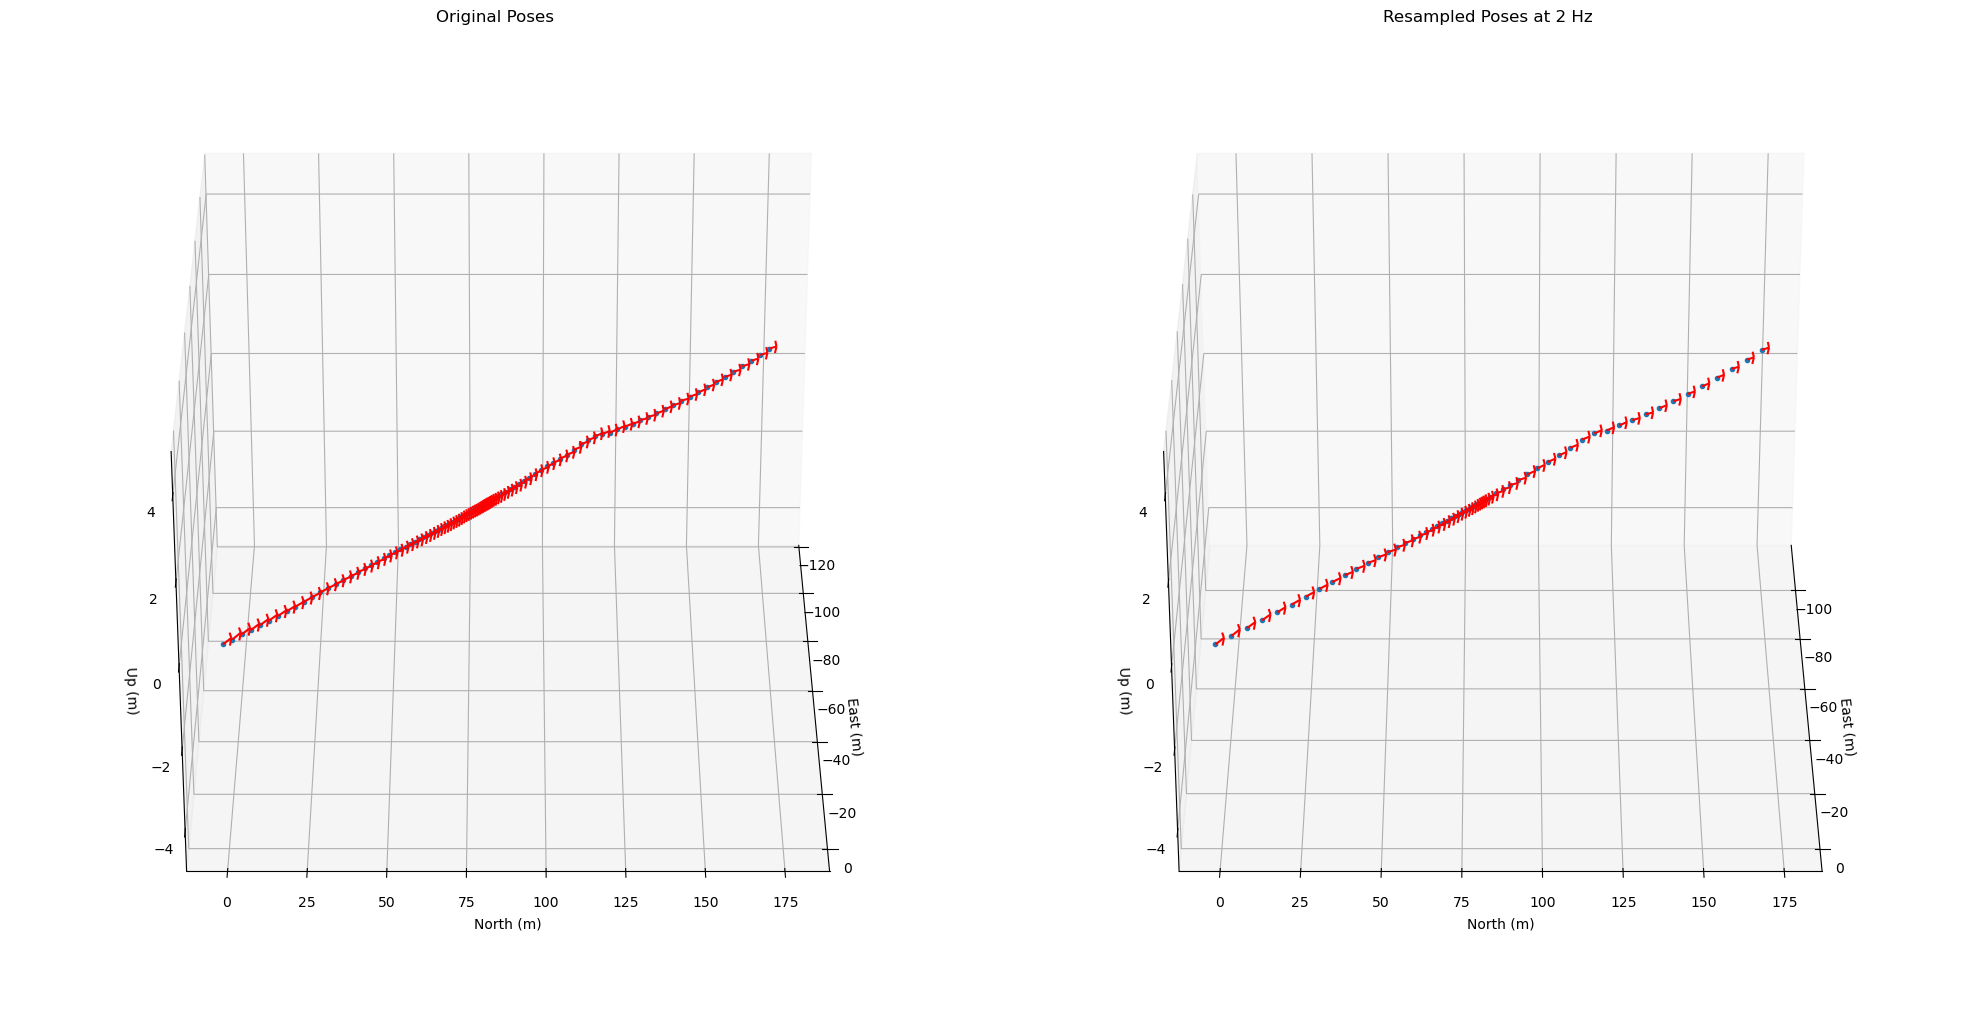

In [13]:
new_poses, new_times = resample_hz(poses, times, target_hz=2)

fig = plt.figure(figsize=(20, 10))
ax0 = fig.add_subplot(121, projection='3d')
ax1 = fig.add_subplot(122, projection='3d')


plot_poses(poses, arrow_length=3, step=1, ax=ax0)
plot_poses(new_poses, arrow_length=3, step=1, ax=ax1)

fig.tight_layout()
# fig.subplots_adjust(wspace=0, hspace=0)
ax0.set_title("Original Poses")
ax1.set_title("Resampled Poses at 2 Hz")

# for ax in [ax0, ax1]:
#     ax.set_box_aspect(None, zoom=0.8)

# rotate for better view
ax0.view_init(elev=30, azim=0)
ax1.view_init(elev=30, azim=0)

plt.show()

Convert to 2D, plot

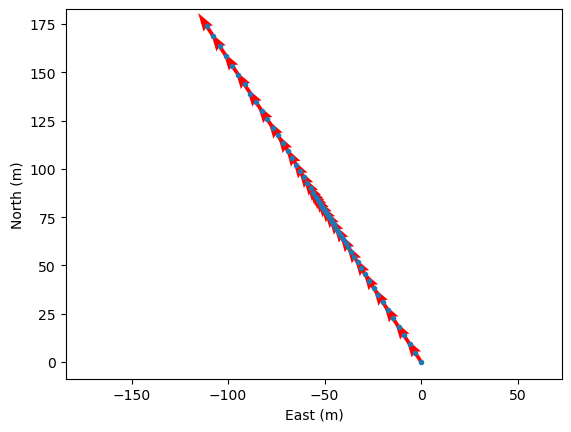

In [14]:
poses_2d = convert_to_2d(new_poses)
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
plot_poses_2d(poses_2d, step=2, ax=ax2)
plt.show()

Infer commands

In [15]:
# Directions: (left, forward, right, unknown)
print("infer_direction:", infer_direction(new_poses))
print("infer_direction_2d:", infer_direction_2d(poses_2d))

infer_direction: [0. 1. 0. 0.]
infer_direction_2d: [0. 1. 0. 0.]


Create segmented list of trajectories

In [16]:
trajs = process_trajectory(poses, times)

In [18]:
# Check all paths in folder

from pathlib import Path

parent_dirs = [r"/home/zhaohaoa/cadc/cadcd/2018_03_06", 
               r"/home/zhaohaoa/cadc/cadcd/2018_03_07",
               r"/home/zhaohaoa/cadc/cadcd/2019_02_27"]


turns_left = {}
turns_right = {}

# total_dir = np.array([0, 0, 0, 0], dtype=np.float64)
for parent_dir_str in parent_dirs:
    parent_dir = Path(parent_dir_str)
    for dir in parent_dir.iterdir():
        novatel_path = dir / "labeled/novatel/data/"
        timestamps_path = dir / "labeled/novatel/timestamps.txt"
        if not novatel_path.exists() or not timestamps_path.exists():
            print(f"Skipping directory: {dir}")
            continue
        print(f"Processing directory: {dir}")
        novatel = load_novatel_data.load_novatel_data(str(novatel_path) + "/")
        poses = convert_novatel_to_pose.convert_novatel_to_pose(novatel)
        times = load_timestamps(str(timestamps_path))
        
        # Plot 2d trajectory
        new_poses, new_times = resample_hz(poses, times, target_hz=2)
        poses_2d = convert_to_2d(new_poses)

        # Infer directions
        dir_2d = infer_direction_2d(poses_2d)
        # total_dir += dir_2d

        if dir_2d[0] == 1:
            turns_left[dir.name] = {
                'poses_2d': poses_2d,
                'times': new_times,
            }
        if dir_2d[2] == 1:
            turns_right[dir.name] = {
                'poses_2d': poses_2d,
                'times': new_times,
            }

        # fig = plt.figure()
        # ax = fig.add_subplot(111)
        # plot_poses_2d(poses_2d, step=2, ax=ax)
        # ax.set_title(f"2D Trajectory for {dir.name} in {parent_dir.name}\nInferred Direction: {dir_2d}")
        # plt.show()
    

Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0008
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0015
Skipping directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/calib
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0018
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0010
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0016
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0013
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0009
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0006
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0012
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0005
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0001
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_06/0002
Skipping directory: /home/zhaohaoa/cadc/cadcd/2018_03_07/calib
Processing directory: /home/zhaohaoa/cadc/cadcd/2018_03_07/0007
Processing directory: /home/zhaohaoa/cadc/

In [21]:
len(turns_left)
len(turns_right)

9

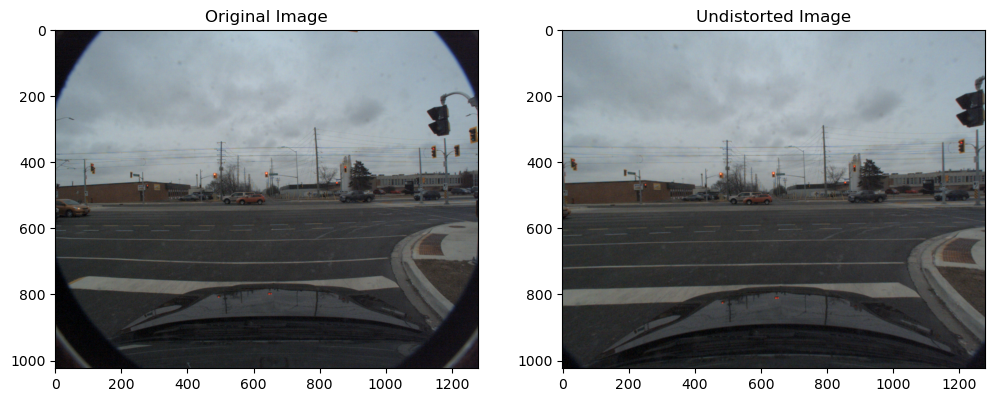

In [26]:
# Test undistort image

import cv2
import yaml

yaml_cfg_path = "/home/zhaohaoa/cadc/cadcd/2018_03_06/calib/00.yaml"
img_path = "/home/zhaohaoa/cadc/cadcd_raw/2018_03_06/0001/raw/image_00/data/0000000000.png"

img = cv2.imread(img_path)
# load yaml
cfg = yaml.safe_load(open(yaml_cfg_path, 'r'))

K = np.array(cfg['camera_matrix']['data']).reshape(3,3)
dist = np.array(cfg['distortion_coefficients']['data'], dtype=np.float32)

h, w = img.shape[:2]
# newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), alpha=0)
undistorted = cv2.undistort(img, K, dist, None, K)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.set_title("Original Image")
ax2.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
ax2.set_title("Undistorted Image")
plt.show()

Max pixel difference: 197
Shapes: (1024, 1280, 3) (1024, 1280, 3)


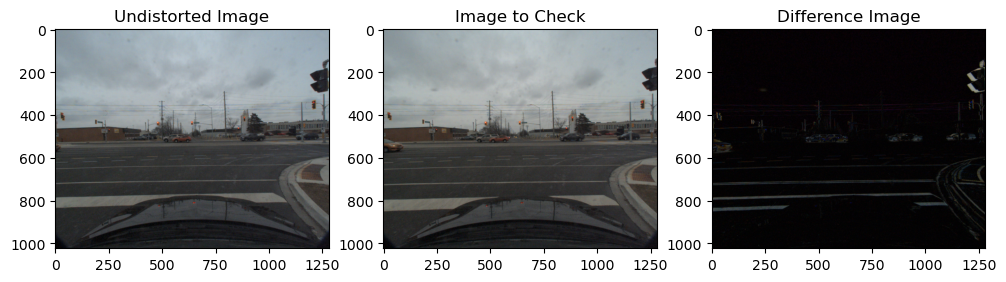

In [27]:
# Check if two images are the same

to_check_path = r"/home/zhaohaoa/cadc/cadcd/2018_03_06/0001/labeled/image_00/data/0000000000.png"
img2 = cv2.imread(to_check_path)


difference = cv2.absdiff(undistorted, img2)
print("Max pixel difference:", np.max(difference))
print("Shapes:", undistorted.shape, img2.shape)

# Display difference
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
ax1.set_title("Undistorted Image")
ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.set_title("Image to Check")
ax3.imshow(difference)
ax3.set_title("Difference Image")
plt.show()